# Homework 3: SOLUTIONS
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26
 

## Problem 1

Use pymc to fit this functions to the provided dataset (see below): 
$y(x) = A * x * np.cos(B*x) + C$. Show plots with
the progress of chains, the corner plot, and a plot that shows data (with uncertainties for both x and y axis)
and the best-fit model. What are the values of the best-fit model parameters (give 95% credible intervals)? 


## Problem 2

Use emcee to fit two functions to the provided dataset (see below).

**Function 1:** 5-th order polynomial, $y(x) = \sum_{j=0}^5 c_j \, x^j$.

**Function 2:** $y(x) = A * x * np.cos(B*x) + C$. 

Show plots with
the progress of chains and the corner plots for both models, and a plot that shows data (with uncertainties for y axis) and both best fit models. Which model is a better description of provided data? How strong is the evidence? 

## Problem 3

Apply Bayesian Blocks Algorithm to period distribution of LINEAR variable stars (see below) and
compare the result to classical (Knuth's) uniform bin width histogram.
Plot histograms on both linear and log scale. 

## Problem 4

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does Markov Chain Monte Carlo method do?  

* What can Metropolis-Hastings algorithm do? 

* What is Bayesian Blocks algorithm useful for? How is it different from Knuth's histogram? 

# Homework 3: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import norm

# MCMC library
import pymc as pm
# analysis and visualization helper for pymc
import arviz as az

# here we are using emcee
import emcee 
import corner 

%matplotlib inline

Write your solutions below...

## Problem 1

### dataset to fit:

In [2]:
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
xErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [3]:
# hint: use these prior ranges for model parameters 
thetaMin = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMax = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)

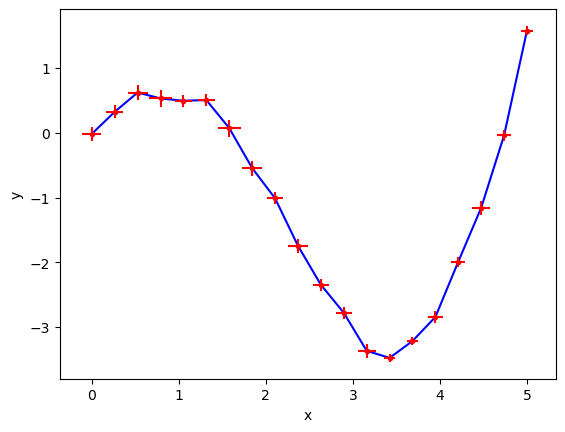

In [4]:
# let's take a look at the data  
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.plot(xObs, yObs, c='blue')
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='r', marker='.', ls='None', label='data')
plt.show() 

In [5]:
## model to fit
def TrigModel(theta, x):
    # y(x) = A * x * np.cos(B*x) + C
    return theta[0] * x * np.cos(theta[1]*x) + theta[2]


def myMCMC(xObs, yObs, xErr, yErr, doXerror=True, draws=1000, tune=200):

    with pm.Model() as model:

        # 1) priors
        theta = {}
        kmax = 3
        thetaMin = (0.5,  0.5, -0.2)
        thetaMax = (1.5,  1.5,  0.2)
        # set uniform priors in provided min-max limits
        for i in range(0,kmax):
            theta[i] = pm.Uniform(str(i), thetaMin[i], thetaMax[i])

        # 2) latent variable for x-error
        if doXerror:
            xLatent = pm.Normal('x', mu=xObs, sigma=xErr, shape=xObs.shape)
        else:
            xLatent = xObs

        # 3) likelihood
        print('evaluating trigonometric model')
        mu = TrigModel(theta, xLatent)
        y = pm.Normal('y', mu=mu, sigma=yErr, observed=yObs)

        # sampling  
        step = pm.Metropolis()
        idata = pm.sample(draws=draws, tune=tune, random_seed=123, return_inferencedata=True)

    return idata

In [6]:
# obtain MCMC results
tracesT = myMCMC(xObs, yObs, xErr, yErr, doXerror=True, draws=50000, tune=10000)

evaluating trigonometric model


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [0, 1, 2, x]


Output()

Sampling 4 chains for 10_000 tune and 50_000 draw iterations (40_000 + 200_000 draws total) took 22 seconds.


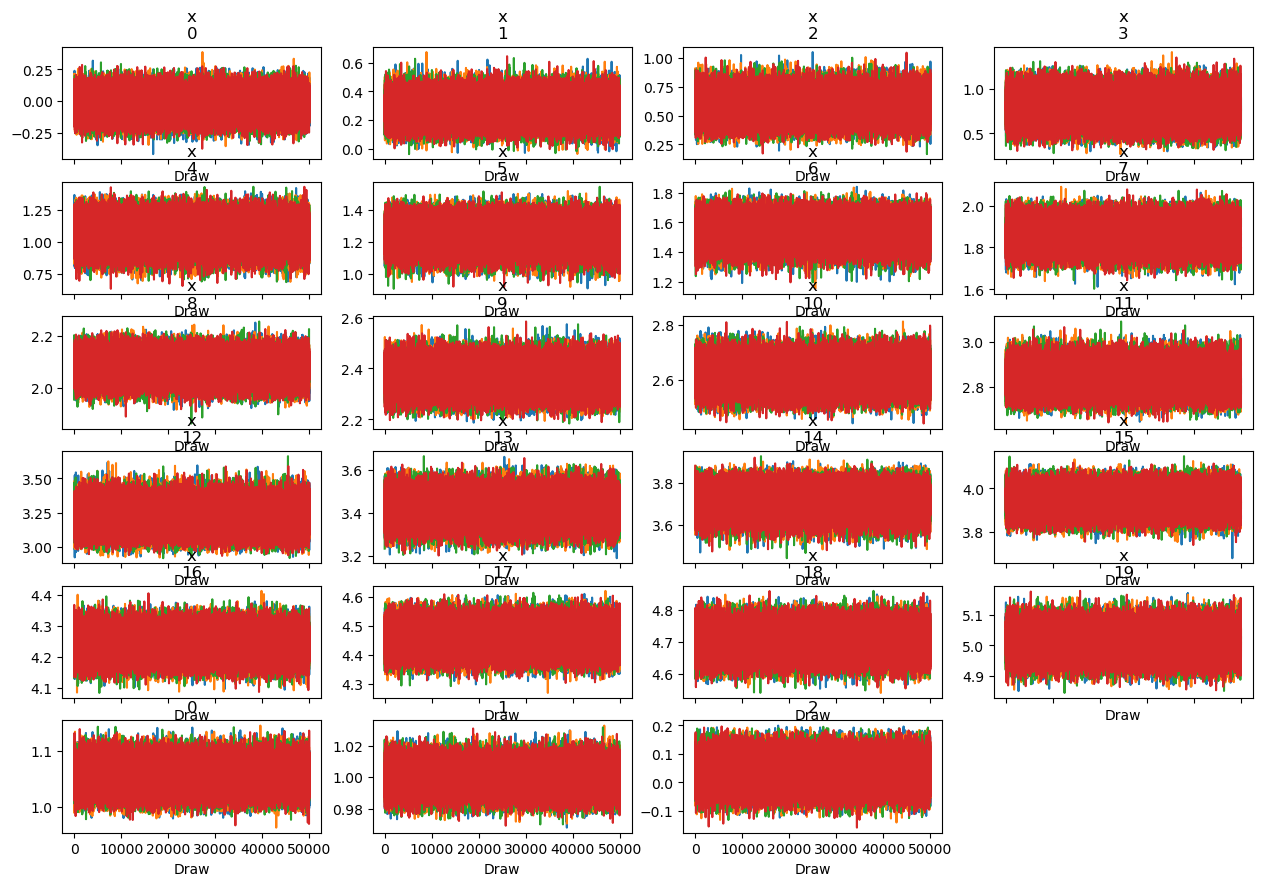

In [7]:
az.plot_trace(tracesT)

In [8]:
# compute summary statistics
summaryT = az.summary(tracesT)
# best-fit parameters (posterior means)
bfT = summaryT["mean"] 
thetaT = [
    float(bfT["0"]),
    float(bfT["1"]),
    float(bfT["2"])
    ]
thetaT

[1.055, 0.99964, 0.0353]

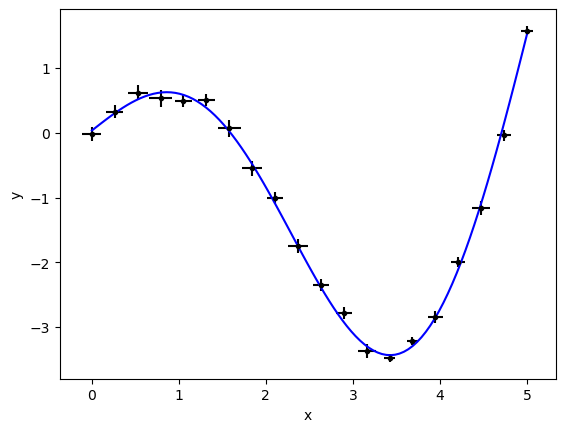

In [9]:
# let's take a look at the data  
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.plot(xObs, yObs, c='blue')
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='black', marker='.', ls='None', label='data')

# show trig model
x = np.linspace(np.min(xObs), np.max(xObs), 100)
yT = TrigModel(thetaT, x)
ax.plot(x, yT, c='blue')

plt.show() 

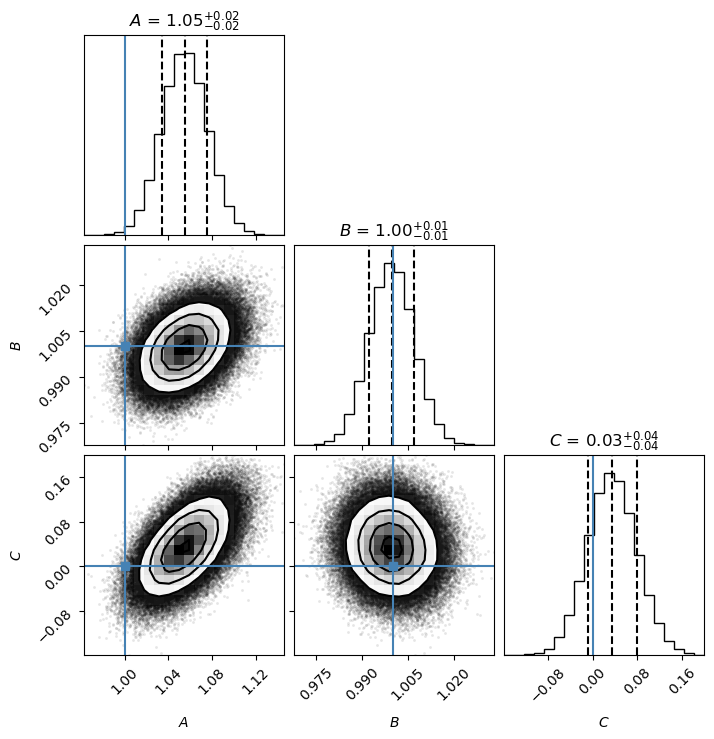

In [10]:
# extract posterior samples correctly
posterior = az.extract(
    tracesT,
    group="posterior",
    var_names=["0", "1", "2"]
)

samples = np.vstack([
    posterior["0"].values,
    posterior["1"].values,
    posterior["2"].values
]).T

Ls = [r"$A$", r"$B$", r"$C$"] 
truth = [1.0, 1.0, 0]

fig = corner.corner(
    samples,
    truths=truth,
    labels=Ls,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

## Problem 2

### here we will use emcee, not pymc

In [11]:
### this is the provided dataset to fit (note that x errors are assumed negligible): 
xObs = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
yObs = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

In [12]:
# hints: 
# use these prior ranges for polynomial model parameters (Function 1)
thetaMin = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMax = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)
# use these prior ranges for trigonometric model parameters (Function 2)
thetaMin = (0.5,  0.5, -0.2)
thetaMax = (1.5,  1.5,  0.2)

In [13]:
# this function computes polynomial models given some data x
# and parameters theta
def PolyModel(theta, x):
    """Polynomial model of degree (len(theta) - 1)"""
    return sum(t * x ** n for (n, t) in enumerate(theta))

In [14]:
LOGPRIOR_MIN = -np.inf 

def yModel(modelType, x, theta):
    if modelType == 'poly':
        return PolyModel(theta, x)
    else:
        return TrigModel(theta, x)

def log_flat_prior(theta, thetaMin, thetaMax):
    for k in range(np.size(theta)):
        if (theta[k]<thetaMin[k]): return LOGPRIOR_MIN 
        if (theta[k]>thetaMax[k]): return LOGPRIOR_MIN   
    return 1.0 
    
def log_prior(theta, thetaMin, thetaMax):
    return log_flat_prior(theta, thetaMin, thetaMax)

def log_likelihood(modelType, theta, x, y, yErr):
    # we are assuming that measurement errors are Gaussian and known
    # and thus ignoring normalization factors in the likelihood
    return -np.sum((y - yModel(modelType, x, theta)) ** 2 / yErr ** 2)

def log_posterior(theta, modelType, x, y, yErr, thetaMin, thetaMax):
    logLikelihood = log_likelihood(modelType, theta, x, y, yErr)
    logPrior = log_prior(theta, thetaMin, thetaMax)
    if logPrior > LOGPRIOR_MIN:
        return logPrior + logLikelihood
    else:
        return LOGPRIOR_MIN + logLikelihood 

## first evaluate polynomial model

In [15]:
# limits for flat priors for polynomial model
thetaPtrue = np.array([ 0.02299728,  0.88370827,  0.72181362, -1.34934527,  0.39291482, -0.03131753])
thetaMin = (-1.0, -2.0, -2.0, -2.0, -2.0, -2.0)
thetaMax = ( 1.0,  2.0,  2.0,  2.0,  2.0,  2.0)
# The number of trace results will be nwalkers * nsteps
ndim = 6  # number of parameters in the model
modelType = 'poly'
np.random.seed(0)

# emcee combines multiple "walkers", each of which is its own MCMC chain. 
nwalkers = 100   # number of MCMC walkers
# starting guesses for parameters 
starting_guesses = 0.1*np.random.random((nwalkers, ndim))
# set starting guesses at the center of flat priors
for k in range(np.size(thetaMin)):
    starting_guesses[:,k] += 0.5*(thetaMin[k]+thetaMax[k])

In [16]:
nburn = 5000    # "burn-in" period to let chains stabilize
nsteps = 20000  # number of MCMC steps to take, about 1 min runtime
## WARNING: 
##   this is the main step, which can take many minutes (depending on your machine)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[modelType, xObs, yObs, yErr, thetaMin, thetaMax])
%time sampler.run_mcmc(starting_guesses, nsteps) 
print("done")

CPU times: user 21.4 s, sys: 48.4 ms, total: 21.4 s
Wall time: 21.4 s
done


In [17]:
emcee_trace = sampler.chain[:, nburn:, :].reshape(-1, ndim).T
thetaFitPoly= []
for k in range(ndim):
    thetaFitPoly.append(np.median(emcee_trace[k]))
    print(thetaPtrue[k], np.median(emcee_trace[k]), np.std(emcee_trace[k]), np.size(emcee_trace[k]))

0.02299728 0.023296662924357628 0.06954184980920185 1500000
0.88370827 0.8858970184895938 0.30198838781873644 1500000
0.72181362 0.7147879106341255 0.3864653290957545 1500000
-1.34934527 -1.3440298288884431 0.19562909878907053 1500000
0.39291482 0.3915456688093094 0.042559119229965255 1500000
-0.03131753 -0.031199132323341698 0.0033262360215907945 1500000


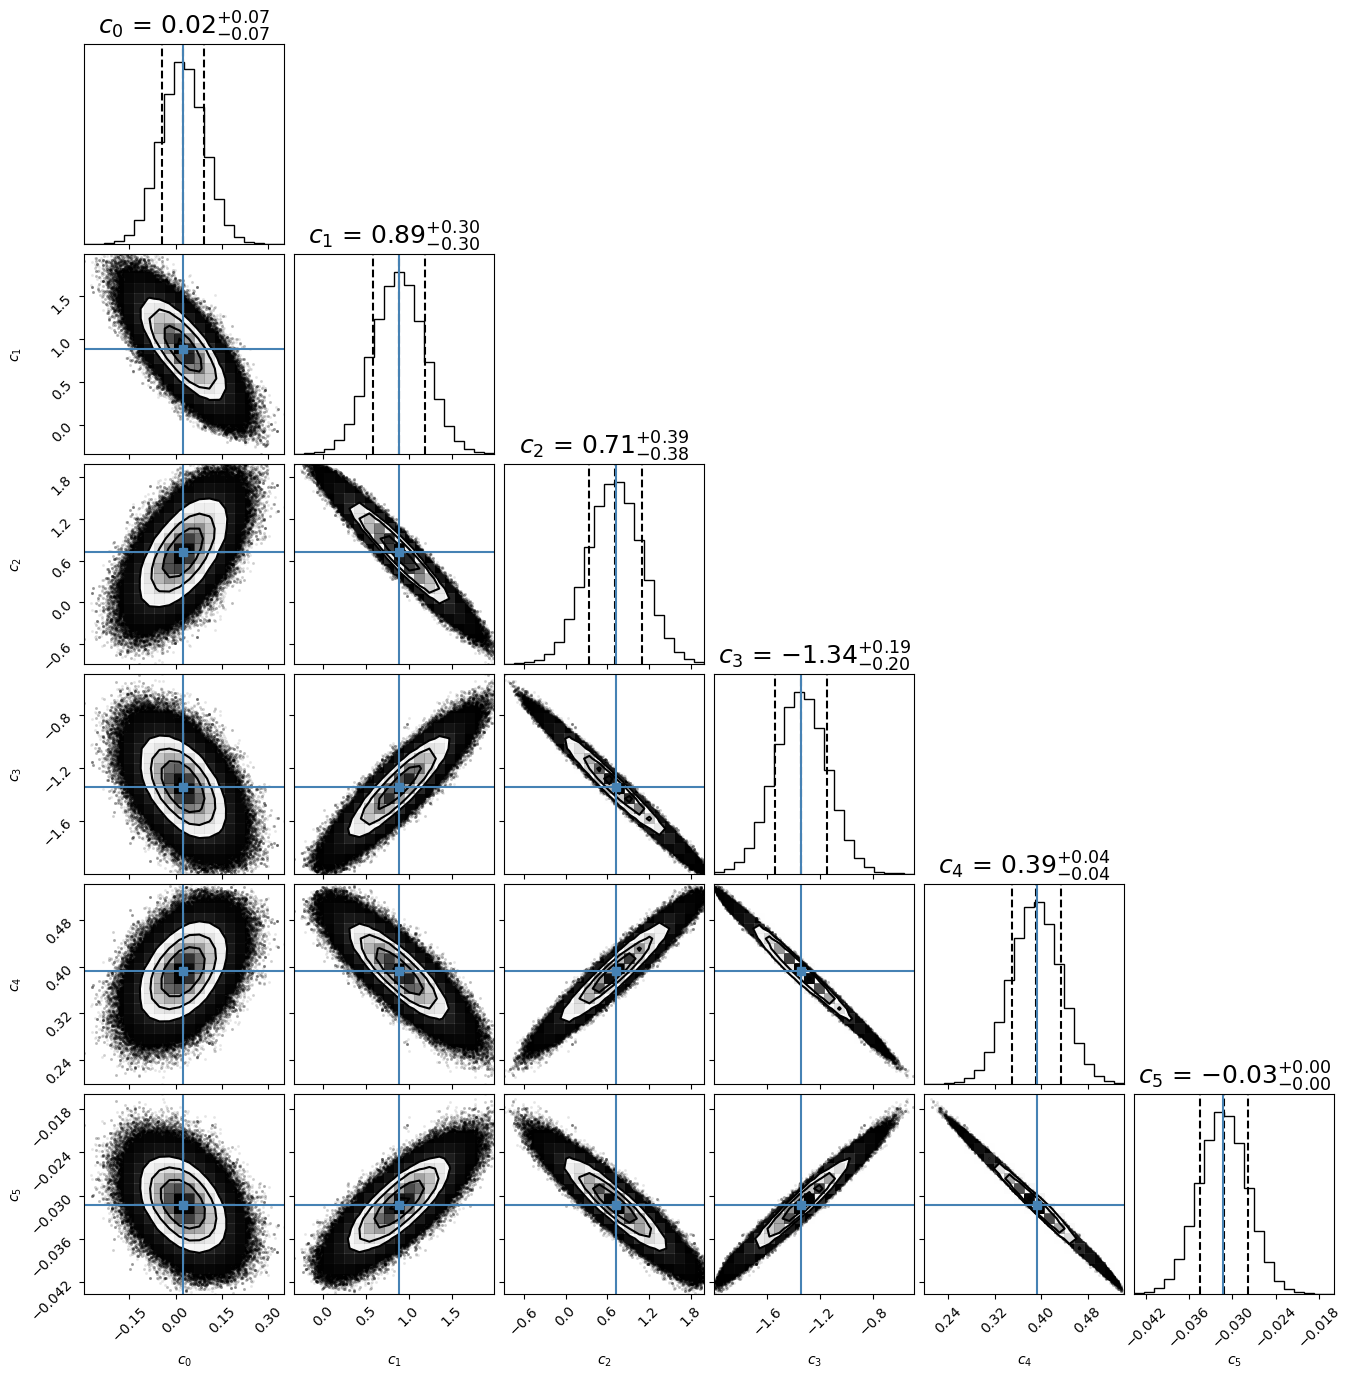

In [18]:
samples = np.vstack([emcee_trace[k] for k in range(0,ndim)]).T
Ls = [r"$c_0$", r"$c_1$", r"$c_2$", r"$c_3$", r"$c_4$", r"$c_5$"] 

fig = corner.corner(
    samples, 
    truths=thetaPtrue, 
    labels=Ls, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 18}
)    
plt.show()

## and now evaluate trigonometric model

In [19]:
# limits for flat priors for trigonometric model
thetaTtrue = np.array([1.0, 1.0, 0.0])
thetaMin = (0.5,  0.5, -0.2)
thetaMax = (1.5,  1.5,  0.2)
# The number of trace results will be nwalkers * nsteps
ndim = 3  # number of parameters in the model
modelType = 'trig'
np.random.seed(0)

# emcee combines multiple "walkers", each of which is its own MCMC chain. 
nwalkers = 100   # number of MCMC walkers
# starting guesses for parameters 
starting_guesses = 0.1*np.random.random((nwalkers, ndim))
# set starting guesses at the center of flat priors
for k in range(np.size(thetaMin)):
    starting_guesses[:,k] += 0.5*(thetaMin[k]+thetaMax[k])

In [20]:
nburn = 5000    # "burn-in" period to let chains stabilize
nsteps = 20000  # number of MCMC steps to take, about 1 min runtime
## WARNING: 
##   this is the main step, which can take many minutes (depending on your machine)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[modelType, xObs, yObs, yErr, thetaMin, thetaMax])
%time sampler.run_mcmc(starting_guesses, nsteps) 
print("done")

CPU times: user 11 s, sys: 69.7 ms, total: 11.1 s
Wall time: 11.1 s
done


In [21]:
emcee_trace = sampler.chain[:, nburn:, :].reshape(-1, ndim).T
thetaFitTrig = []
for k in range(ndim):
    thetaFitTrig.append(np.median(emcee_trace[k]))
    print(thetaTtrue[k], np.median(emcee_trace[k]), np.std(emcee_trace[k]), np.size(emcee_trace[k]))

1.0 1.0492720927170733 0.009190386859823513 1500000
1.0 0.9981981196324909 0.0014903854224514238 1500000
0.0 0.0499957879251072 0.02173252989450937 1500000


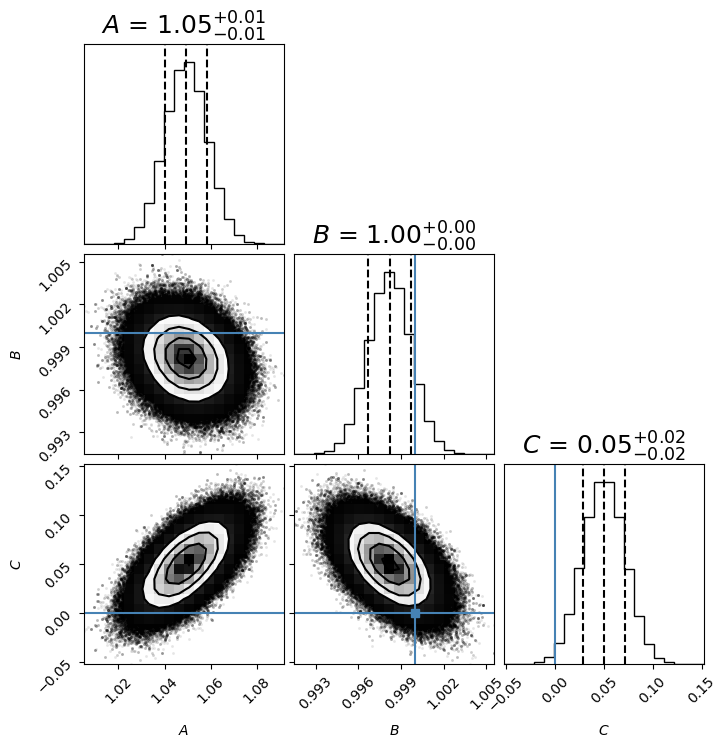

In [22]:
samples = np.vstack([emcee_trace[k] for k in range(0,ndim)]).T
Ls = [r"$A$", r"$B$", r"$C$"] 

fig = corner.corner(
    samples, 
    truths=thetaTtrue, 
    labels=Ls, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 18}
)    
plt.show()

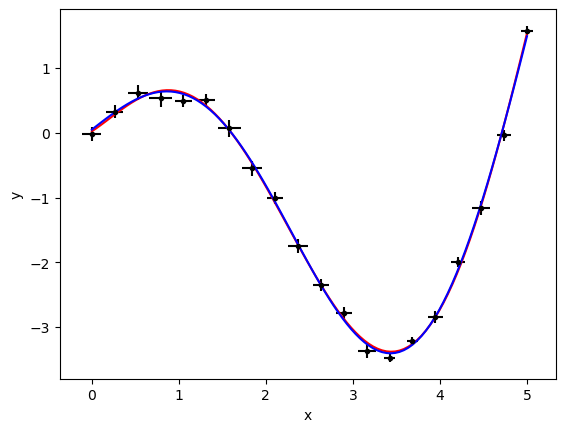

In [23]:
# let's take a look at the data  
ax = plt.figure().add_subplot(111)
ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.plot(xObs, yObs, c='blue')
ax.errorbar(xObs, yObs, xerr=xErr, yerr=yErr, color='black', marker='.', ls='None', label='data')

# show poly model
x = np.linspace(np.min(xObs), np.max(xObs), 100)
# yP = PolyModel(thetaPtrue, x)
yP = PolyModel(thetaFitPoly, x)
ax.plot(x, yP, c='red')

# show trig model
#yT = TrigModel(thetaTtrue, x)
yT = TrigModel(thetaFitTrig, x)
ax.plot(x, yT, c='blue')

plt.show() 

In [24]:
## let's evaluate chi2 and BIC for the two best-fit models
## Function 1 (polynomial)
yfitF1 = PolyModel(thetaFitPoly, xObs)
chi2F1 = np.sum(((yObs-yfitF1)/yErr)**2) 
NparamF1 = 6
BICF1 = chi2F1 + NparamF1 *np.log(np.size(xObs))
## Function 2 (trigonometric)
yfitF2 = TrigModel(thetaFitTrig, xObs)
chi2F2 = np.sum(((yObs-yfitF2)/yErr)**2) 
NparamF2 = 3
BICF2 = chi2F2 + NparamF2 *np.log(np.size(xObs))

In [25]:
print ("       MODEL             CHI2            BIC")
print ('    Function 1:', chi2F1, BICF1)
print ('    Function 2:', chi2F2, BICF2) 

       MODEL             CHI2            BIC
    Function 1: 18.817708589574003 36.79210223089795
    Function 2: 17.719109087862236 26.706305908524207


## Problem 3
### dataset to fit (requires astroML!): 

In [26]:
# fetch data
from astroML.datasets import fetch_LINEAR_geneva
data = fetch_LINEAR_geneva()
x = data['logP']
N = x.size
print('read LINEAR dataset: N =', N)

read LINEAR dataset: N = 6146


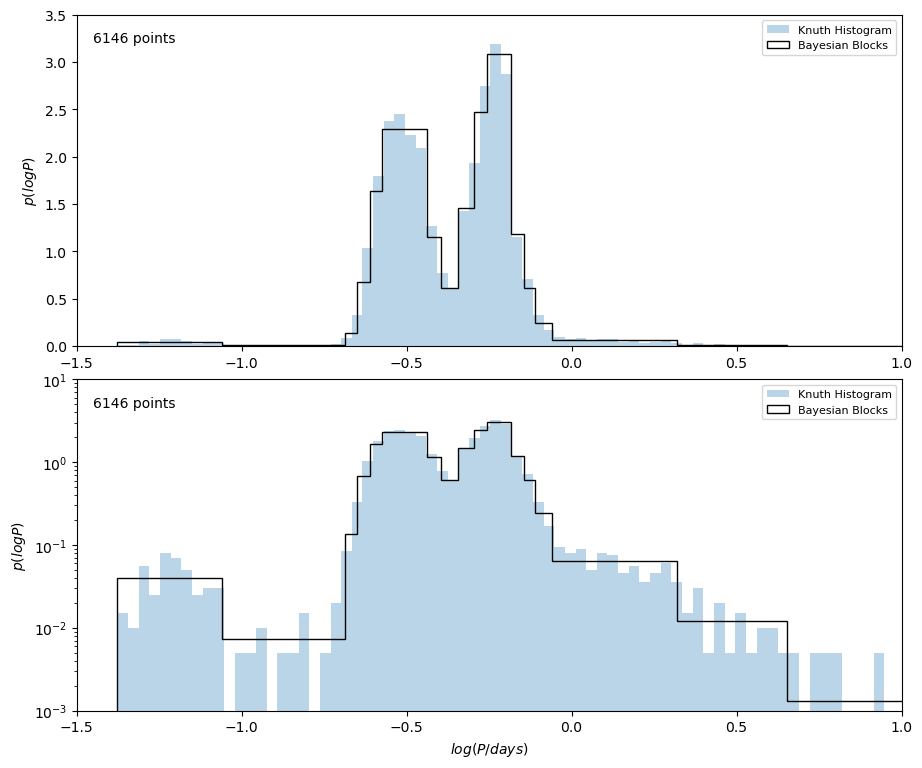

In [27]:
from astroML.plotting import hist

fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(bottom=0.08, top=0.95, right=0.95, hspace=0.1)

# linear scale
ax = fig.add_subplot(211)
hist(x, bins='knuth', ax=ax, density=True,  
         histtype='stepfilled', alpha=0.3,
         label='Knuth Histogram')
hist(x, bins='blocks', ax=ax, density=True,  
         histtype='step', color='black', alpha=0.99,
         label="Bayesian Blocks")
# label the plot
ax.text(0.02, 0.95, "%i points" % N, ha='left', va='top',
            transform=ax.transAxes)
ax.set_ylabel('$p(logP)$')
ax.legend(loc='upper right', prop=dict(size=8))

ax.set_xlim(-1.5, 1.0)
ax.set_ylim(0, 3.5)

# log scale
ax = fig.add_subplot(212)
hist(x, bins='knuth', ax=ax, density=True, log=True,
         histtype='stepfilled', alpha=0.3,
         label='Knuth Histogram')
hist(x, bins='blocks', ax=ax, density=True, log=True,
         histtype='step', color='black', alpha=0.99,
         label="Bayesian Blocks")
# label the plot
ax.text(0.02, 0.95, "%i points" % N, ha='left', va='top',
            transform=ax.transAxes)
ax.set_ylabel('$p(logP)$')
ax.legend(loc='upper right', prop=dict(size=8))

ax.set_xlabel('$log(P/days)$')
ax.set_xlim(-1.5, 1.0)
ax.set_ylim(0.001, 10)

plt.show()



## Problem 4

### What does Markov Chain Monte Carlo method do?

MCMC uses a pseudo-random number generator to generate a set of numbers, called chain, from an arbitrary, typically multi-dimensional distribution (that we know how to compute). When this multi-dimensional distribution corresponds to a posterior probability distribution, the resulting chain can be used to estimate various derivatives and integrals that appear in Bayesian statistical analysis. MCMC is much better than the brute force grid search. 

### What can Metropolis-Hastings algorithm do?

Metropolis-Hastings algorithm is an efficient implementation of MCMC that is based on rejection rules for generated random numbers. It enables a superior numerical integration compared to generic Monte Carlo. The Metropolis-Hastings algorithm adopts acceptance probability 
$$ p_{\rm acc}(\theta_i,\theta_{i+1}) = { p(\theta_{i+1}) \over p(\theta_i) }, $$
where the proposed point $\theta_{i+1}$ is drawn from an *arbitrary* symmetric density distribution $K(\theta_{i+1}\,|\,\theta_i)$. A Gaussian distribution centered on 
$\theta_i$ is often used for $K(\theta_{i+1}|\theta_i)$. 

The original Metropolis algorithm is based on a symmetric proposal distribution,
$K(\theta_{i+1}|\theta_i) =  K(\theta_i|\theta_{i+1})$, which then cancels out from
the acceptance probability. **In this case, $\theta_{i+1}$ is always accepted if
$p(\theta_{i+1}) > p(\theta_i)$, and if not, then it is accepted with a probability**
$p(\theta_{i+1})/p(\theta_i)$ < 1.


### What is Bayesian Blocks algorithm useful for? How is it different from Knuth's histogram?

Bayesian Blocks algorithm is a generalized of classical histogram to a model with varying bin width,
unlike Knuth's histogram which assume a constant bin width. 